In [55]:
import pandas as pd
import numpy as np

In [56]:
#load and merge
def load_dta(path):
    df = pd.read_stata(path, convert_categoricals=False)
    df.columns = df.columns.str.strip().str.upper()
    return df

sec2 = load_dta("data/GSEC2.dta")
sec3 = load_dta("data/GSEC3.dta")
sec4 = load_dta("data/GSEC4.dta")
sec5 = load_dta("data/GSEC5.dta")

sec1 = load_dta("data/GSEC1.dta")
sec15A = load_dta("data/Section 15 A.dta")
sec15B = load_dta("data/Section 15 B.dta")
sec14 = load_dta("data/GSEC14.dta")

# Person Dataset

piddata = sec2.merge(sec3, on=["HHID", "PID"], how="left", validate="1:1", suffixes=("", "_sec3"))
piddata = piddata.merge(sec4, on=["HHID", "PID"], how="left", validate="1:1", suffixes=("", "_sec4"))
piddata = piddata.merge(sec5, on=["HHID", "PID"], how="left", validate="1:1", suffixes=("", "_sec5"))

# HHid dataset

hhiddata = sec1.merge(sec15A, on="HHID", how="left", validate="m:1", suffixes=("", "_sec1"))

#Income dataset

income = (
    sec14.groupby("HHID", as_index=False)
         .agg(asset_value_total=("H14Q5", "sum"))
)

In [57]:
#clean workflow food module

food = sec15B[[
    "HHID", "H15BQ2", "H15BQ3B", "H15BQ3C",
    "H15BQ4", "H15BQ6", "H15BQ8", "H15BQ10"
]].copy()

#rename
food = food.rename(columns={
    "H15BQ2": "food_code",
    "H15BQ3B": "days_consumed",
    "H15BQ3C": "unit_code",
    "H15BQ4": "qty_purchase_home",
    "H15BQ6": "qty_purchase_away",
    "H15BQ8": "qty_homeprod",
    "H15BQ10": "qty_gift"
})

#Basic clean
for col in ["food_code", "unit_code", "qty_purchase_home", "qty_purchase_away", "qty_homeprod", "qty_gift"]:
    food[col] = pd.to_numeric(food[col], errors="coerce")

food = food.dropna(subset=["HHID", "food_code"])

food["total_qty_reported"] = (
    food["qty_purchase_home"].fillna(0)
    + food["qty_purchase_away"].fillna(0)
    + food["qty_homeprod"].fillna(0)
    + food["qty_gift"].fillna(0)
)

# Keep only rows with some positive reported quantity
food = food.loc[food["total_qty_reported"] > 0].copy()

#drop
drop_codes = [148, 149, 152, 153, 155, 156]   # coffee, tea, beer, other alcohol, cigarettes, tobacco
food = food.loc[~food["food_code"].isin(drop_codes)].copy()

# Food category map for density assumptions
food_density_type_map = {
    101:"starch",102:"starch",103:"starch",104:"starch",
    105:"starch",106:"flour",107:"starch",108:"flour",
    109:"starch",110:"grain",111:"grain",112:"grain",
    113:"flour",114:"flour",115:"grain",116:"grain",

    117:"meat",118:"meat",119:"meat",120:"meat",
    121:"meat",122:"fish",123:"fish",124:"protein",

    125:"liquid",126:"powder",127:"oil",128:"oil",129:"oil",

    130:"fruit",131:"fruit",132:"fruit",133:"fruit",134:"fruit",

    135:"veg",136:"veg",137:"veg",138:"veg",139:"veg",

    140:"grain",141:"grain",142:"nut",143:"nut",
    144:"paste",145:"grain",146:"seed",

    147:"sugar",

    148:"powder",   # coffee
    149:"powder",   # tea

    150:"salt",

    151:"liquid",   # soda
    152:"liquid",   # beer
    153:"liquid",   # other alcohol
    154:"liquid",   # other drinks

    155:"prepared_food",  # cigarettes (won't matter if dropped)
    156:"prepared_food",  # other tobacco

    157:"prepared_food",
    158:"liquid",
    159:"liquid",
    160:"liquid",
    161:"prepared_food",

    162:"grain",
    163:"paste",

    164:"veg",165:"veg",167:"veg",168:"veg",
    166:"fruit",169:"fruit",170:"fruit",171:"fruit",

    172:"flour",
    173:"flour",

    174:"fruit",

    175:"liquid"
}
food["food_type"] = food["food_code"].map(food_density_type_map)

exact_kg = {
    1: 1.0,        # kilogram
    2: 0.001,      # gram
    9: 120.0,      # sack 120 kg
    10: 100.0,     # sack 100 kg
    11: 80.0,      # sack 80 kg
    12: 50.0,      # sack 50 kg

    29: 2.0,       # Kimbo/Cowboy/Blueband tin (2 kg)
    30: 1.0,       # Kimbo/Cowboy/Blueband tin (1 kg)
    31: 0.5,       # Kimbo/Cowboy/Blueband tin (0.5 kg)

    37: 20.0,      # basket 20 kg
    38: 10.0,      # basket 10 kg
    39: 5.0,       # basket 5 kg
    40: 2.0,       # basket 2 kg

    41: 1.0,       # loaf 1 kg
    42: 0.5,       # loaf 500 g
    43: 0.2,       # buns 200 g
    44: 0.1,       # buns 100 g
    45: 0.05,

    49: 2.0,       # packet 2 kg
    50: 1.0,       # packet 1 kg
    51: 0.5,       # packet 500 g
    52: 0.25,      # packet 250 g
    53: 0.1,       # packet 100 g

    55: 0.5,       # fish whole up to 1 kg
    56: 0.75,      # fish whole 1-2 kg
    57: 1.0,       # fish whole above 2 kg
    58: 1.0,       # fish cut piece up to 1 kg
    59: 1.5,       # fish cut piece 1-2 kg
    60: 2.0,       # fish cut piece above 2 kg

    61: 1.7,       # tray of 30 eggs

    67: 4.0,       # bunch big
    68: 2.0,       # bunch medium
    69: 0.5        # bunch small
}

unit_to_liters = {
    3: 1.0,        # litre
    4: 0.4,        # akendo = 400 ml
    8: 0.001,      # millilitre

    14: 20.0,      # jerrican 20 lts
    15: 10.0,      # jerrican 10 lts
    16: 5.0,       # jerrican 5 lts
    17: 3.0,       # jerrican 3 lts
    18: 2.0,       # jerrican 2 lts
    19: 1.0,       # jerrican 1 lt

    20: 20.0,      # tin 20 lts
    21: 5.0,       # tin 5 lts
    22: 15.0,      # plastic basin 15 lts

    23: 0.75,      # bottle 750 ml
    24: 0.5,       # bottle 500 ml
    25: 0.35,      # bottle 350 ml
    26: 0.30,      # bottle 300 ml
    27: 0.25,      # bottle 250 ml
    28: 0.15,      # bottle 150 ml

    32: 0.5,       # cup/mug 0.5 lt
    33: 0.25,      # glass 0.25 lt
    35: 0.015,
    36: 0.005,

    71: 2.5,       # gourd 2-5 lts
    72: 7.5,       # gourd 5-10 lts
    73: 10.0,      # gourd above 10 lts
    74: 4.5,       # gologolo 4-5 lts
    75: 2.5,       # calabash 1-5 lts
    76: 5.0,       # calabash above 5 lts
    77: 2.0,       # jug 2 lts
    78: 1.5,       # jug 1.5 lts
    79: 1.0,       # jug 1 lt
    80: 0.05       # tot 50 ml
}

density_map = {
    "liquid": 1.00,
    "oil": 0.92,
    "grain": 0.75,
    "flour": 0.60,
    "sugar": 0.85,
    "salt": 1.20,
    "fruit": 0.65,
    "veg": 0.65,
    "starch": 0.75,
    "meat": 1.00,
    "fish": 1.00,
    "protein": 0.90,
    "nut": 0.60,
    "seed": 0.65,
    "paste": 0.85,
    "powder": 0.50,
    "prepared_food": np.nan
}

count_heap_kg_map = {
    "meat": 0.10,
    "fish": 0.10,
    "protein": 0.10,
    "fruit": 0.167,
    "oil": 1.00,
    "liquid": 1.00,
    "veg": 0.167,
    "grain": 0.167,
    "flour": 0.167,
    "starch": 0.167,
    "sugar": 0.167,
    "salt": 0.167,
    "nut": 0.167,
    "seed": 0.167,
    "paste": 0.167,
    "powder": 0.167,
    "prepared_food": 0.10
}

food["kg_factor_count_heap"] = np.where(
    food["unit_code"].isin([64, 85]),
    food["food_type"].map(count_heap_kg_map),
    np.nan
)

food["kg_factor_exact"] = food["unit_code"].map(exact_kg)
food["liters"] = food["unit_code"].map(unit_to_liters)
food["density"] = food["food_type"].map(density_map)

food["kg_factor_approx"] = food["liters"] * food["density"]

food["kg_factor_final"] = (
    food["kg_factor_exact"]
        .fillna(food["kg_factor_approx"])
        .fillna(food["kg_factor_count_heap"])
)

food["conversion_type"] = np.select(
    [
        food["kg_factor_exact"].notna(),
        food["kg_factor_exact"].isna() & food["kg_factor_approx"].notna(),
        food["kg_factor_exact"].isna() & food["kg_factor_approx"].isna() & food["kg_factor_count_heap"].notna()
    ],
    [
        "exact",
        "approx_volume",
        "approx_count_heap"
    ],
    default="unresolved"
)

food["total_qty"] = (
    food["qty_purchase_home"].fillna(0)
    + food["qty_purchase_away"].fillna(0)
    + food["qty_homeprod"].fillna(0)
    + food["qty_gift"].fillna(0)
)

food["qty_kg"] = food["total_qty"] * food["kg_factor_final"]



In [58]:
#diagnostic
food["conversion_type"].value_counts(dropna=False)
food.loc[food["conversion_type"] == "unresolved", "unit_code"].value_counts(dropna=False)

unit_code
66.0    1783
54.0     674
70.0     399
99.0      92
34.0      35
87.0       7
81.0       4
63.0       3
13.0       2
82.0       1
Name: count, dtype: int64

In [59]:
food_clean = food.loc[food["conversion_type"] != "unresolved"].copy()

food_clean["conversion_type"].value_counts()

conversion_type
exact                13341
approx_count_heap    10704
approx_volume         7124
Name: count, dtype: int64

In [60]:
#Most important foods (by kg)
food_clean.groupby("food_code")["qty_kg"].sum().sort_values(ascending=False)

food_code
105.0    14482.468500
125.0     7015.524999
113.0     6473.487000
108.0     6165.840000
107.0     4295.571750
141.0     4275.356253
127.0     4114.749400
147.0     2270.088125
112.0     2180.169500
102.0     1847.500000
140.0     1819.328107
132.0     1719.353000
116.0     1665.160625
110.0     1583.918750
117.0     1485.980000
136.0     1408.363900
109.0     1399.944000
115.0     1283.632500
101.0     1271.000000
114.0     1106.125000
135.0      744.915350
144.0      694.129375
150.0      649.133000
123.0      633.475000
111.0      580.552000
122.0      531.650000
103.0      499.500000
139.0      459.304000
134.0      437.617750
106.0      431.065000
133.0      422.155750
151.0      362.275000
130.0      308.775250
145.0      305.802251
124.0      305.150000
146.0      265.405376
104.0      261.772500
154.0      245.700000
131.0      226.568000
142.0      213.450000
119.0      212.310000
137.0      210.619000
118.0      205.750000
143.0      196.427500
138.0      187.364000


In [61]:
#export used food codes to xlx

used_food_codes = sorted(food_clean["food_code"].unique())
print(used_food_codes)

food_name_map = {
101:"Matooke (Bunch)",
102:"Matooke (Cluster)",
103:"Matooke (Heap)",
104:"Matooke (Others)",
105:"Sweet Potatoes (Fresh)",
106:"Sweet Potatoes (Dry flour)",
107:"Cassava (Fresh)",
108:"Cassava (Dry Flour)",
109:"Irish Potatoes",
110:"Rice",
111:"Maize (grains)",
112:"Maize (cobs)",
113:"Maize (flour)",
114:"Bread",
115:"Millet",
116:"Sorghum",
117:"Beef",
118:"Pork",
119:"Goat Meat",
120:"Other Meat",
121:"Chicken",
122:"Fresh Fish",
123:"Dry/Smoked Fish",
124:"Eggs",
125:"Fresh Milk",
126:"Infant Formula Foods",
127:"Cooking Oil",
128:"Ghee",
129:"Margarine / Butter",
130:"Passion Fruits",
131:"Sweet Bananas",
132:"Mangoes",
133:"Oranges",
134:"Other Fruits",
135:"Onions",
136:"Tomatoes",
137:"Cabbages",
138:"Dodo",
139:"Other Vegetables",
140:"Beans (fresh)",
141:"Beans (dry)",
142:"Groundnuts (in shell)",
143:"Groundnuts (shelled)",
144:"Groundnuts (pounded)",
145:"Peas (fresh)",
146:"Simsim",
147:"Sugar",
148:"Coffee",
149:"Tea",
150:"Salt",
151:"Soda",
152:"Beer",
153:"Other Alcoholic Drinks",
154:"Other Drinks",
155:"Cigarettes",
156:"Other Tobacco",
157:"Restaurant Food",
158:"Restaurant Soda",
159:"Restaurant Beer",
160:"Restaurant Juice",
161:"Restaurant Other Foods",
162:"Peas (dry)",
163:"Groundnuts (paste)",
164:"Green Pepper",
165:"Pumpkins",
166:"Avocado",
167:"Carrots",
168:"Eggplants",
169:"Watermelon",
170:"Pineapple",
171:"Pawpaw",
172:"Wheat Flour",
173:"Chapati",
174:"Apples",
175:"Water"
}

food_code_table = pd.DataFrame({
    "food_code": used_food_codes
})

food_code_table["food_name"] = food_code_table["food_code"].map(food_name_map)

food_code_table.to_excel("foods_for_calorie_table3.xlsx", index=False)





[np.float64(101.0), np.float64(102.0), np.float64(103.0), np.float64(104.0), np.float64(105.0), np.float64(106.0), np.float64(107.0), np.float64(108.0), np.float64(109.0), np.float64(110.0), np.float64(111.0), np.float64(112.0), np.float64(113.0), np.float64(114.0), np.float64(115.0), np.float64(116.0), np.float64(117.0), np.float64(118.0), np.float64(119.0), np.float64(120.0), np.float64(121.0), np.float64(122.0), np.float64(123.0), np.float64(124.0), np.float64(125.0), np.float64(126.0), np.float64(127.0), np.float64(128.0), np.float64(129.0), np.float64(130.0), np.float64(131.0), np.float64(132.0), np.float64(133.0), np.float64(134.0), np.float64(135.0), np.float64(136.0), np.float64(137.0), np.float64(138.0), np.float64(139.0), np.float64(140.0), np.float64(141.0), np.float64(142.0), np.float64(143.0), np.float64(144.0), np.float64(145.0), np.float64(146.0), np.float64(147.0), np.float64(150.0), np.float64(151.0), np.float64(154.0), np.float64(158.0), np.float64(159.0), np.float64(

In [43]:
#household roster

#agg hh members in last 7 days
sec15A["hh_members_present"] = (
    sec15A["H15A1"].fillna(0) +
    sec15A["H15A2"].fillna(0) +
    sec15A["H15A3"].fillna(0) +
    sec15A["H15A4"].fillna(0)
)

sec15A["visitors_present"] = (
    sec15A["H15A5"].fillna(0) +
    sec15A["H15A6"].fillna(0) +
    sec15A["H15A7"].fillna(0) +
    sec15A["H15A8"].fillna(0)
)

sec15A["people_present_7days"] = (
    sec15A["hh_members_present"] +
    sec15A["visitors_present"]
)

sec15A_agg = sec15A[[
    "HHID",
    "hh_members_present",
    "visitors_present",
    "people_present_7days"
]].copy()


roster = piddata[["HHID","PID","H2Q3","H2Q8","H2Q5"]].copy()

roster = roster.rename(columns={
"H2Q3":"sex",
"H2Q8":"age",
"H2Q5":"months_present"
})

roster["adult"] = roster["age"] >= 18
roster["child"] = roster["age"] < 18

hh_roster = (
    roster.groupby("HHID")
    .agg(
        hh_size=("PID","count"),
        adults=("adult","sum"),
        children=("child","sum")
    )
    .reset_index()
)

hh_roster = hh_roster.merge(
    sec15A_agg,
    on="HHID",
    how="left",
    validate="1:1"
)



In [62]:
#Calorie requirement (calories per adult equivalent)

def calorie_ratio(row):
    age = row["age"]
    sex = row["sex"]

    if age <= 6:
        return 0.52 if sex==1 else 0.48
    elif age <= 18:
        return 0.88 if sex==1 else 0.72
    elif age <= 60:
        return 1.04 if sex==1 else 0.84
    else:
        return 0.92 if sex==1 else 0.72

roster["ae_weight"] = roster.apply(calorie_ratio, axis=1)

hh_ae = (
    roster.groupby("HHID")
    .agg(
        hh_size=("PID","count"),
        ae_roster=("ae_weight","sum")
    )
    .reset_index()
)

#merge
hh_ae = hh_ae.merge(sec15A_agg, on="HHID", how="left")

hh_ae["ae_adjusted"] = (
    hh_ae["ae_roster"] *
    (hh_ae["hh_members_present"])
)

#ae_adjusted is the Adult-Equivalents in the household last 7 days



In [63]:
#Food groups + add to cleaned food

food_group_map = {

# STARCHY STAPLES
101:"starchy_staples",102:"starchy_staples",103:"starchy_staples",104:"starchy_staples",
105:"starchy_staples",106:"starchy_staples",107:"starchy_staples",108:"starchy_staples",
109:"starchy_staples",110:"starchy_staples",111:"starchy_staples",112:"starchy_staples",
113:"starchy_staples",114:"starchy_staples",
115:"starchy_staples",116:"starchy_staples",
172:"starchy_staples",173:"starchy_staples",

# PULSES / NUTS / SEEDS
140:"pulses_nuts",141:"pulses_nuts",142:"pulses_nuts",143:"pulses_nuts",
144:"pulses_nuts",163:"pulses_nuts",
145:"pulses_nuts",162:"pulses_nuts",
146:"pulses_nuts",

# FATS
127:"fats",128:"fats",129:"fats",

# DAIRY
125:"dairy",126:"dairy",

# MEAT / FISH / EGGS
117:"meat_fish_eggs",118:"meat_fish_eggs",119:"meat_fish_eggs",
120:"meat_fish_eggs",121:"meat_fish_eggs",
122:"meat_fish_eggs",123:"meat_fish_eggs",
124:"meat_fish_eggs",

# FRUITS
130:"fruits",131:"fruits",132:"fruits",133:"fruits",134:"fruits",
166:"fruits",
169:"fruits",170:"fruits",171:"fruits",
174:"fruits",

# VEGETABLES
135:"vegetables",136:"vegetables",137:"vegetables",138:"vegetables",
139:"vegetables",
164:"vegetables",165:"vegetables",167:"vegetables",168:"vegetables",

# SUGAR
147:"sugar",

# SALT (optional but sometimes included)
150:"salt",

# BEVERAGES (not usually used in diet diversity)
148:"beverages",149:"beverages",
151:"beverages",152:"beverages",153:"beverages",154:"beverages",

# NON-FOOD / TOBACCO (can be dropped later)
155:"tobacco",156:"tobacco",

# FOOD AWAY FROM HOME
157:"prepared_food",158:"prepared_food",
159:"prepared_food",160:"prepared_food",161:"prepared_food",

# WATER
175:"water"
}

food_clean["food_group"] = food_clean["food_code"].map(food_group_map)



In [48]:
calorie_table = pd.read_excel("foods_for_calorie_table2.xlsx")

print(calorie_table.columns)


Index(['food_code', 'kcal/kg'], dtype='str')


In [74]:
#integrating kcal/kg
calorie_table = calorie_table.rename(columns={
    "kcal/kg": "kcal_per_kg"
})

calorie_table = calorie_table[["food_code", "kcal_per_kg"]].copy()
calorie_table["food_code"] = pd.to_numeric(calorie_table["food_code"], errors="coerce")
calorie_table["kcal_per_kg"] = pd.to_numeric(calorie_table["kcal_per_kg"], errors="coerce")

food_kcal = food_clean.merge(calorie_table, on="food_code", how="left", validate="m:1")

food_kcal = food_kcal.loc[
    ~food_kcal["food_group"].isin(["beverages", "prepared_food"])
].copy()


In [75]:
#Check which foods are still missing kcal?
print(food_kcal.loc[food_kcal["kcal_per_kg"].isna(), "food_code"].drop_duplicates().tolist())


[]


In [134]:
#Compute kcal per row
food_kcal["kcal_total"] = food_kcal["qty_kg"] * food_kcal["kcal_per_kg"]

food_kcal = food_kcal.loc[
    ~food_kcal["food_group"].isin(["salt"])
].copy()

# Aggregate total household kcal
hh_kcal = (
    food_kcal.groupby("HHID", as_index=False)
    .agg(hh_kcal_total=("kcal_total", "sum"))
)

#Aggregate household kcal by food group
hh_kcal_group = (
    food_kcal.groupby(["HHID", "food_group"], as_index=False)
    .agg(group_kcal=("kcal_total", "sum"))
)

# 5c. Optional: wide household × food group table
hh_kcal_group_wide = (
    hh_kcal_group.pivot(index="HHID", columns="food_group", values="group_kcal")
    .fillna(0)
    .reset_index()
)

# 6. Merge with adult-equivalent dataset
hh_final = hh_ae.merge(hh_kcal, on="HHID", how="left", validate="1:1")
hh_final = hh_final.merge(hh_kcal_group_wide, on="HHID", how="left", validate="1:1")

# Fill missing calories with zero
hh_final["hh_kcal_total"] = hh_final["hh_kcal_total"].fillna(0)

# Optional: kcal per adult equivalent
hh_final["kcal_per_ae"] = hh_final["hh_kcal_total"] / hh_final["ae_adjusted"]

hh_final["kcal_per_ae_day"] = hh_final["kcal_per_ae"] / 7

#Calorie shares x food groups

hh_group_kcal = (
    food_kcal.groupby(["HHID","food_group"], as_index=False)
    .agg(group_kcal=("kcal_total","sum"))
)

hh_total_kcal = (
    hh_group_kcal.groupby("HHID", as_index=False)
    .agg(total_kcal=("group_kcal","sum"))
)

hh_group_kcal = hh_group_kcal.merge(hh_total_kcal, on="HHID")

hh_group_kcal["kcal_share"] = (
    hh_group_kcal["group_kcal"] /
    hh_group_kcal["total_kcal"]
)




In [135]:
print(hh_final[["hh_kcal_total", "ae_adjusted", "kcal_per_ae_day"]].describe())

print(
    food_kcal.loc[food_kcal["kcal_per_kg"].isna(), ["food_code", "food_group"]]
    .drop_duplicates()
    .sort_values("food_code")
)

       hh_kcal_total  ae_adjusted  kcal_per_ae_day
count    2975.000000  2926.000000      2922.000000
mean    61118.756472    33.110075              inf
std     55329.654708    36.486924              NaN
min         0.000000     0.000000         0.000000
25%     25800.950000    10.410000       164.021309
50%     46933.700000    23.180000       304.232190
75%     80488.155000    44.400000       561.500149
max    656177.200000   516.120000              inf
Empty DataFrame
Columns: [food_code, food_group]
Index: []


C:\Users\Carl\anaconda3\envs\econometrics\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [136]:
food_kcal.groupby("food_group")["kcal_total"].sum().sort_values(ascending=False)

food_group
starchy_staples    9.713407e+07
fats               3.731900e+07
pulses_nuts        2.308752e+07
sugar              8.785241e+06
meat_fish_eggs     8.124189e+06
dairy              4.331936e+06
fruits             1.953021e+06
vegetables         1.093316e+06
Name: kcal_total, dtype: float64

In [140]:
#Merging total asset value to householdframe

hh_final = hh_final.merge(income, on="HHID", how="left", validate="1:1")


In [141]:
hh_final["asset_value_total"].quantile([0.01,0.05,0.1,0.2,0.4,0.6,0.8,0.9,0.95,0.99])

0.01        10000.0
0.05       102300.0
0.10       235000.0
0.20       720000.0
0.40      2218800.0
0.60      5235000.0
0.80     13811000.0
0.90     31624200.0
0.95     73205000.0
0.99    297621300.0
Name: asset_value_total, dtype: float64

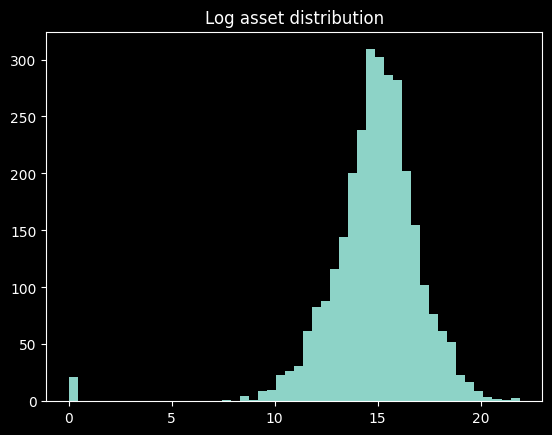

In [93]:
#logged dist plot

plt.hist(np.log(hh_final["asset_value_total"] + 1), bins=50)
plt.title("Log asset distribution")
plt.show()

#scatter value x Kcal per ae day

plt.scatter(np.log(hh_final["asset_value_total"] + 1), hh_final["hh_kcal_total"], alpha=0.3)
plt.xlabel("Log asset value")
plt.ylabel("Calories per adult equivalent")
plt.show()


In [142]:
#wealth quantiles and poor/rich household gen

hh_final["wealth_quintile"] = pd.qcut(
    np.log(hh_final["asset_value_total"] + 1),
    5,
    labels=[1,2,3,4,5]
)

poor = hh_final[hh_final["wealth_quintile"] == 1]
rich = hh_final[hh_final["wealth_quintile"] == 5]

In [146]:
# EAT-LANCET-INDEX-TARGET

eat_targets = {
"starchy_staples":0.34,
"pulses_nuts":0.23,
"fats":0.1788,
"dairy":0.0612,
"meat_fish_eggs":0.0604,
"fruits":0.0504,
"sugar":0.048,
"vegetables":0.0312
}

weights = {
"starchy_staples":1.2,
"pulses_nuts":1.5,
"fats":1.2,
"dairy":1.0,
"meat_fish_eggs":1.3,
"fruits":1.5,
"vegetables":1.5,
"sugar":2.0
}

# Mean Deviation from Lancet by wealth quantile
hh_group_kcal["group_kcal"] = hh_group_kcal["group_kcal"].fillna(0)

hh_group_kcal["kcal_share"] = (
    hh_group_kcal["group_kcal"] /
    hh_group_kcal["total_kcal"]
)

hh_group_kcal["target_share"] = hh_group_kcal["food_group"].map(eat_targets)

hh_group_kcal["deviation"] = (
    hh_group_kcal["kcal_share"] -
    hh_group_kcal["target_share"]
)

def deviation(row):

    share = row["kcal_share"]
    target = row["target_share"]
    group = row["food_group"]

    if group in ["starchy_staples","fats","sugar"]:
        d = max(0, share-target)
    else:
        d = max(0, target-share)

    return d

hh_group_kcal["dev"] = hh_group_kcal.apply(deviation, axis=1)

hh_group_kcal["penalty"] = (
    hh_group_kcal["dev"]**2 *
    hh_group_kcal["food_group"].map(weights)
)

eat_index = (
    hh_group_kcal.groupby("HHID",as_index=False)
    .agg(eat_index_raw=("penalty","sum"))
)

eat_index["eat_index"] = 1 - (
    eat_index["eat_index_raw"] /
    eat_index["eat_index_raw"].quantile(0.99)
)

eat_index["eat_index"] = eat_index["eat_index"].clip(0,1)



In [147]:
# Mean Deviation from Lancet by wealth quantile

hh_final = hh_final.merge(
    eat_index[["HHID", "eat_index"]],
    on="HHID",
    how="left",
    validate="1:1"
)

poor_index = hh_final.loc[
    hh_final["wealth_quintile"]==1,
    "eat_index"
].mean()

rich_index = hh_final.loc[
    hh_final["wealth_quintile"]==5,
    "eat_index"
].mean()


In [148]:
food_kcal.groupby("HHID")["food_group"].nunique().sort_values()

HHID
1021000409      1
3113000301      1
108300060802    1
3021000212      1
3203002108      1
               ..
102100110903    8
3103000602      8
3103000707      8
1021000312      8
1021000212      8
Name: food_group, Length: 2852, dtype: int64

In [145]:
hh_final = hh_final.drop(
    columns=["eat_index_x", "eat_index_y"],
    errors="ignore"
)

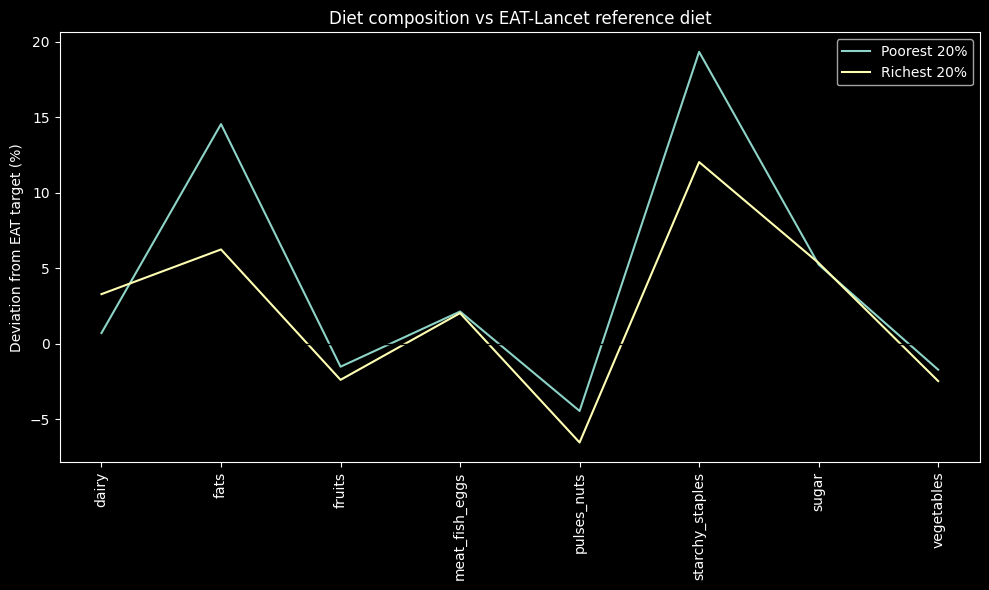

In [157]:
#poorest and richest avg for food groups

hh_group_kcal = hh_group_kcal.merge(
    hh_final[["HHID","wealth_quintile"]],
    on="HHID",
    how="left"
)

poor_avg = (
    hh_group_kcal.loc[hh_group_kcal["wealth_quintile"]==1]
    .groupby("food_group")
    .agg(mean_share=("kcal_share","mean"))
    .reset_index()
)

rich_avg = (
    hh_group_kcal.loc[hh_group_kcal["wealth_quintile"]==5]
    .groupby("food_group")
    .agg(mean_share=("kcal_share","mean"))
    .reset_index()
)

targets = pd.DataFrame(
    list(eat_targets.items()),
    columns=["food_group","target_share"]
)

poor_avg = poor_avg.merge(targets,on="food_group")
rich_avg = rich_avg.merge(targets,on="food_group")

poor_avg["diff"] = poor_avg["mean_share"] - poor_avg["target_share"]
rich_avg["diff"] = rich_avg["mean_share"] - rich_avg["target_share"]

poor_avg["diff"] *= 100
rich_avg["diff"] *= 100

plot_df = poor_avg[["food_group","diff"]].rename(columns={"diff":"poor"})
plot_df = plot_df.merge(
    rich_avg[["food_group","diff"]].rename(columns={"diff":"rich"}),
    on="food_group"
)

import matplotlib.pyplot as plt

groups = plot_df["food_group"]

plt.figure(figsize=(10,6))

plt.plot(groups, plot_df["poor"], label="Poorest 20%")
plt.plot(groups, plot_df["rich"], label="Richest 20%")

plt.axhline(0,color="black",linewidth=1)

plt.xticks(rotation=90)

plt.ylabel("Deviation from EAT target (%)")
plt.title("Diet composition vs EAT-Lancet reference diet")

plt.legend()

plt.tight_layout()

plt.savefig("eat_lancet_deviation_plot.png", dpi=300)

plt.show()


In [155]:
hh_group_kcal = hh_group_kcal.drop(
    columns=["wealth_quintile", "wealth_quintile_x", "wealth_quintile_y"],
    errors="ignore"
)

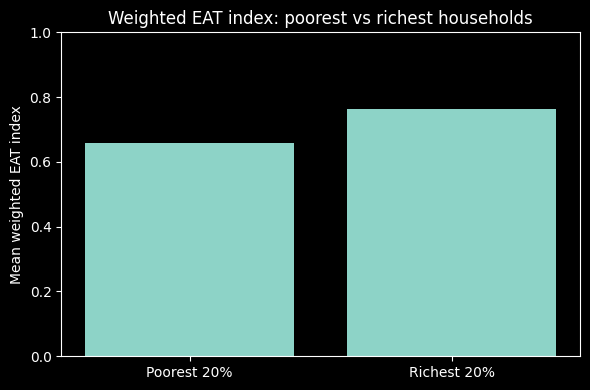

In [158]:
#Bar chart of group means

compare_df = (
    hh_final.loc[hh_final["wealth_quintile"].isin([1, 5]), ["wealth_quintile", "eat_index"]]
    .copy()
)

compare_df["group"] = compare_df["wealth_quintile"].map({
    1: "Poorest 20%",
    5: "Richest 20%"
})

mean_index = (
    compare_df.groupby("group", as_index=False)
    .agg(mean_eat_index=("eat_index", "mean"))
)

plt.figure(figsize=(6, 4))
plt.bar(mean_index["group"], mean_index["mean_eat_index"])
plt.ylabel("Mean weighted EAT index")
plt.title("Weighted EAT index: poorest vs richest households")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("eat_index_poor_vs_rich_bar.png", dpi=300)
plt.show()

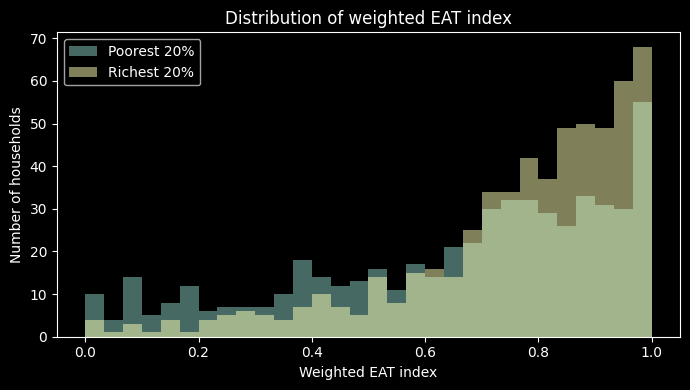

In [159]:
# distribution plot

plt.figure(figsize=(7, 4))

poor_vals = hh_final.loc[hh_final["wealth_quintile"] == 1, "eat_index"].dropna()
rich_vals = hh_final.loc[hh_final["wealth_quintile"] == 5, "eat_index"].dropna()

plt.hist(poor_vals, bins=30, alpha=0.5, label="Poorest 20%")
plt.hist(rich_vals, bins=30, alpha=0.5, label="Richest 20%")

plt.xlabel("Weighted EAT index")
plt.ylabel("Number of households")
plt.title("Distribution of weighted EAT index")
plt.legend()
plt.tight_layout()
plt.savefig("eat_index_distribution_poor_vs_rich.png", dpi=300)
plt.show()



C:\Users\Carl\AppData\Local\Temp\ipykernel_7284\601558035.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=["Poorest 20%", "Richest 20%"])


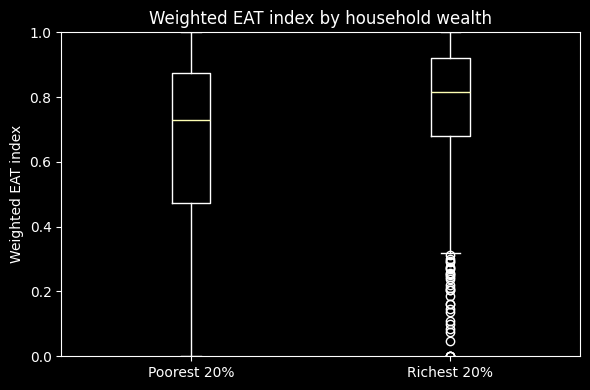

In [160]:
plot_data = hh_final.loc[hh_final["wealth_quintile"].isin([1, 5]), ["wealth_quintile", "eat_index"]].copy()
plot_data["group"] = plot_data["wealth_quintile"].map({
    1: "Poorest 20%",
    5: "Richest 20%"
})

groups = [
    plot_data.loc[plot_data["group"] == "Poorest 20%", "eat_index"].dropna(),
    plot_data.loc[plot_data["group"] == "Richest 20%", "eat_index"].dropna()
]

plt.figure(figsize=(6, 4))
plt.boxplot(groups, labels=["Poorest 20%", "Richest 20%"])
plt.ylabel("Weighted EAT index")
plt.title("Weighted EAT index by household wealth")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("eat_index_boxplot_poor_vs_rich.png", dpi=300)
plt.show()

In [161]:
eat_index["eat_index_raw"].quantile(0.99)


np.float64(0.5806432104170318)

In [162]:
eat_index["eat_index_raw"].quantile([0.9, 0.95, 0.99])


0.90    0.388256
0.95    0.467570
0.99    0.580643
Name: eat_index_raw, dtype: float64